In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when printing
pd.set_option('display.max_columns', None)

In [2]:
df_impact = pd.read_csv('../data/raw/environmental_impact.csv')
df_routes = pd.read_csv('../data/raw/all_routes_cleaned.csv')

print(df_impact['operator'].value_counts())
print(df_impact.shape)
print(df_routes.shape)

operator
SNCF                                     1333
DB                                        590
SBB (Schweizerische Bundesbahnen SBB)     433
ÖBB                                       188
SNCF VOYAGEURS                            182
                                         ... 
TCDD, BDŽ                                   1
UZ, ÖBB                                     1
GWR                                         1
GA                                          1
ČD                                          1
Name: count, Length: 99, dtype: int64
(3678, 18)
(3678, 10)


In [3]:
df_impact.head()

,route_name,origin,destination,service_type,route_name_simple,origin_country,destination_country,distance_km,operator,type,train_gco2_pkm,plane_gco2_pkm,train_co2_kg,plane_co2_kg,co2_savings_kg,savings_percent,emission_source,calculation_date
0,ICE 18,Hauptbahnhof,Berlin Gesundbrunnen,day,→ Berlin Gesundbrunnen,DE,DE,238.64,DB,day,14,144,3.34,34.36,31.02,90.3,Back-on-Track 2022,2026-03-22
1,IC 51,Hauptbahnhof,Dortmund Hbf,day,→ Dortmund,DE,DE,256.33,DB,day,14,144,3.59,36.91,33.32,90.3,Back-on-Track 2022,2026-03-22
2,ICE 28,Hamburg Altona S,Hauptbahnhof,day,Hamburg Altona S →,DE,DE,296.60,DB,day,14,144,4.15,42.71,38.56,90.3,Back-on-Track 2022,2026-03-22
3,IC 51,Hauptbahnhof,Koln Hbf,day,→ Koln,DE,DE,285.66,DB,day,14,144,4.00,41.14,37.14,90.3,Back-on-Track 2022,2026-03-22
4,ICE 11,Munchen Hbf,Hauptbahnhof,day,Munchen →,DE,DE,317.10,DB,day,14,144,4.44,45.66,41.22,90.3,Back-on-Track 2022,2026-03-22


In [4]:
df_impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   route_name           3678 non-null   str    
 1   origin               3678 non-null   str    
 2   destination          3678 non-null   str    
 3   service_type         3678 non-null   str    
 4   route_name_simple    3678 non-null   str    
 5   origin_country       3678 non-null   str    
 6   destination_country  3678 non-null   str    
 7   distance_km          3492 non-null   float64
 8   operator             3678 non-null   str    
 9   type                 3678 non-null   str    
 10  train_gco2_pkm       3678 non-null   int64  
 11  plane_gco2_pkm       3678 non-null   int64  
 12  train_co2_kg         3492 non-null   float64
 13  plane_co2_kg         3492 non-null   float64
 14  co2_savings_kg       3492 non-null   float64
 15  savings_percent      3492 non-null   float64
 16 

In [5]:
df_impact.isnull().sum()

route_name               0
origin                   0
destination              0
service_type             0
route_name_simple        0
origin_country           0
destination_country      0
distance_km            186
operator                 0
type                     0
train_gco2_pkm           0
plane_gco2_pkm           0
train_co2_kg           186
plane_co2_kg           186
co2_savings_kg         186
savings_percent        186
emission_source          0
calculation_date         0
dtype: int64

In [6]:
df_routes.isnull().sum()

route_name               0
origin                   0
destination              0
service_type             0
route_name_simple        0
origin_country           0
destination_country      0
distance_km            186
operator                 0
type                     0
dtype: int64

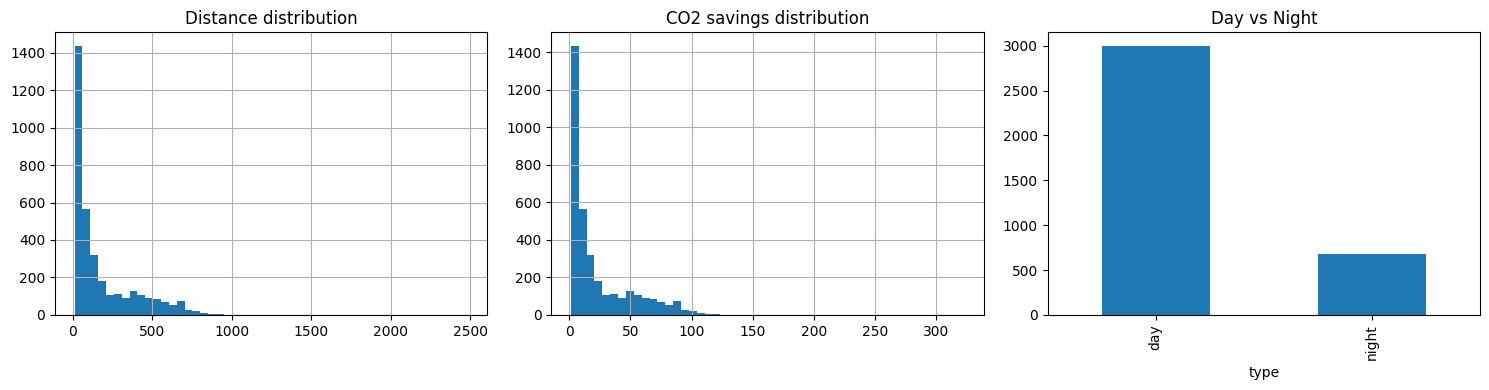

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_impact['distance_km'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distance distribution')

df_impact['co2_savings_kg'].hist(bins=50, ax=axes[1])
axes[1].set_title('CO2 savings distribution')

df_impact['type'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Day vs Night')

plt.tight_layout()
plt.savefig('../evaluation/plots/eda_distributions.png')
plt.show()

In [8]:
# Check what columns all_routes_cleaned has that environmental_impact doesn't
print("In routes but not in impact:", 
      set(df_routes.columns) - set(df_impact.columns))

# Check distance range properly
print("\nDistance stats:")
print(df_impact['distance_km'].describe())

# How many routes are actually in the competitive zone
mask = (df_impact['distance_km'] >= 300) & (df_impact['distance_km'] <= 1500)
print(f"\nRoutes between 300-1500km: {mask.sum()} out of {len(df_impact)}")

# Operator coverage
print(f"\nTotal unique operators: {df_impact['operator'].nunique()}")
print(f"\nTop operators cover:")
top = df_impact['operator'].value_counts().head(5)
print(top)
print(f"That's {top.sum()} out of {len(df_impact)} routes ({top.sum()/len(df_impact)*100:.1f}%)")

In routes but not in impact: set()

Distance stats:
count    3492.000000
mean      177.144341
std       206.018886
min        10.050000
25%        33.372500
50%        81.905000
75%       259.012500
max      2482.420000
Name: distance_km, dtype: float64

Routes between 300-1500km: 783 out of 3678

Total unique operators: 99

Top operators cover:
operator
SNCF                                     1333
DB                                        590
SBB (Schweizerische Bundesbahnen SBB)     433
ÖBB                                       188
SNCF VOYAGEURS                            182
Name: count, dtype: int64
That's 2726 out of 3678 routes (74.1%)


In [9]:
df_ademe = pd.read_csv('../data/external/ademe_base_carbone.csv', sep=';', encoding='latin-1', low_memory=False)

# Filter for transport rows only
df_transport = df_ademe[
    df_ademe['Nom base français'].str.contains(
        'train|ferr|rail|TGV|TER|avion|vol|aérien|intercit|night|nuit', 
        case=False, na=False
    ) |
    df_ademe['Tags français'].str.contains(
        'transport|ferroviaire|aérien|avion', 
        case=False, na=False
    )
]

# Show relevant columns only
cols = ['Nom base français', 'Nom attribut français', 'Unité français', 
        'Total poste non décomposé', 'Localisation géographique']

print(f"Found {len(df_transport)} transport rows")
print(df_transport[cols].to_string())

Found 2081 transport rows
                                                                         Nom base français                                                          Nom attribut français           Unité français Total poste non décomposé Localisation géographique
2                              """Goûter sec fourré (""""sandwiché"""") parfum chocolat"""                                                                            NaN   kgCO2e/kg de poids net                      7,55       France continentale
3                                """Goûter sec fourré (""""sandwiché"""") parfum fruits"""                                                                            NaN   kgCO2e/kg de poids net                       3,4       France continentale
4                       """Goûter sec fourré (""""sandwiché"""") parfum lait ou vanille"""                                                                            NaN   kgCO2e/kg de poids net                      7,55       France

In [10]:
df_ademe = pd.read_csv('../data/external/ademe_base_carbone.csv', sep=';', encoding='latin-1', low_memory=False)
print(df_ademe.columns.tolist())

['Type Ligne', "Identifiant de l'élément", 'Structure', "Type de l'élément", "Statut de l'élément", 'Nom base français', 'Nom base anglais', 'Nom base espagnol', 'Nom attribut français', 'Nom attribut anglais', 'Nom attribut espagnol', 'Nom frontière français', 'Nom frontière anglais', 'Nom frontière espagnol', 'Code de la catégorie', 'Tags français', 'Tags anglais', 'Tags espagnol', 'Unité français', 'Unité anglais', 'Unité espagnol', 'Contributeur', 'Autres Contributeurs', 'Programme', 'Url du programme', 'Source', 'Localisation géographique', 'Sous-localisation géographique français', 'Sous-localisation géographique anglais', 'Sous-localisation géographique espagnol', 'Date de création', 'Date de modification', 'Période de validité', 'Incertitude', 'Réglementations', 'Transparence', 'Qualité', 'Qualité TeR', 'Qualité GR', 'Qualité TiR', 'Qualité C', 'Qualité P', 'Qualité M', 'Commentaire français', 'Commentaire anglais', 'Commentaire espagnol', 'Type poste', 'Nom poste français', 'N

In [11]:
# Filter for passenger transport only, per passenger km
df_passenger = df_ademe[
    (df_ademe['Unité français'] == 'kgCO2e/passager.km') &
    (df_ademe['Nom base français'].str.contains(
        'Train|TGV|TER|Intercit|Avion|Autocar|Métro|RER', 
        case=False, na=False))
]

print(df_passenger[['Nom base français', 'Nom attribut français', 
                     'Total poste non décomposé', 
                     'Localisation géographique']].to_string())

                 Nom base français                          Nom attribut français Total poste non décomposé Localisation géographique
603                        Autocar                                         Gazole                    0,0295       France continentale
604                        Autocar                                         Gazole                  5,79E-03       France continentale
605                        Autocar                                         Gazole                    0,0237       France continentale
606                        Autocar                                         Gazole                    0,0376       France continentale
607                        Autocar                                         Gazole                  7,64E-03       France continentale
608                        Autocar                                         Gazole                    0,0255       France continentale
609                        Autocar                            

In [12]:
# Filter just trains and planes, clean view
transport = df_ademe[
    (df_ademe['Unité français'] == 'kgCO2e/passager.km') &
    (df_ademe['Nom base français'].str.contains(
        'Train|TGV|TER|Intercit|Avion', case=False, na=False))
][['Nom base français', 'Nom attribut français', 
   'Total poste non décomposé', 'Localisation géographique']].drop_duplicates()

print(transport.to_string())
print('\nShape:', transport.shape)

                 Nom base français                         Nom attribut français Total poste non décomposé Localisation géographique
793              Avion (voyageurs)              0-50 sièges, trajet de 0-1000 km                     0,374                     Monde
794              Avion (voyageurs)              0-50 sièges, trajet de 0-1000 km                     0,309                     Monde
795              Avion (voyageurs)              0-50 sièges, trajet de 0-1000 km                         0                     Monde
796              Avion (voyageurs)              0-50 sièges, trajet de 0-1000 km                    0,0646                     Monde
797              Avion (voyageurs)           0-50 sièges, trajet de 1000-2000 km                     0,496                     Monde
798              Avion (voyageurs)           0-50 sièges, trajet de 1000-2000 km                      0,41                     Monde
799              Avion (voyageurs)           0-50 sièges, trajet de 1

In [21]:
# Fix decimal comma to decimal point and convert to float
df_ademe['Total poste non décomposé'] = (
    df_ademe['Total poste non décomposé']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(' ', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Now rerun the filter
train_co2 = df_ademe[
    (df_ademe['Unité français'] == 'kgCO2e/passager.km') &
    (df_ademe['Nom base français'].str.contains(
        'TGV|TER|Intercit|Train grandes|Train de voy', 
        case=False, na=False)) &
    (df_ademe['Total poste non décomposé'] > 0)
][['Nom base français', 'Nom attribut français', 
   'Total poste non décomposé', 'Localisation géographique']]

print(train_co2.to_string())

                 Nom base français     Nom attribut français  Total poste non décomposé Localisation géographique
11538                   Intercités                      2021                    0.00991       France continentale
11539                   Intercités                      2021                    0.00673       France continentale
11541                   Intercités                      2021                    0.00318       France continentale
11542                   Intercités                      2022                    0.00898       France continentale
11543                   Intercités                      2022                    0.00580       France continentale
11545                   Intercités                      2022                    0.00318       France continentale
11546                   Intercités                      2022                    0.00750       France continentale
11547                   Intercités                      2022                    0.00580 